# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [190]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

In [191]:
os.getcwd()

'/Users/hannahwu/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3'

In [192]:
os.listdir("..")

['hw_3', 'hw_2', 'cory-baird.ipynb', 'hw_1.ipynb', 'hanna.ipynb']

In [193]:
df = pd.read_csv("../../../data/hw/hw_3/data_gpr_daily_recent.csv")
df.head(2)

,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date1,GPRD_MA30,GPRD_MA7,event,var_name,var_label
0,19850101,216,230.04,275.20,153.03,1/1/1985,230.04,230.04,NaN,DAY,DAY
1,19850102,315,115.68,146.77,87.44,1/2/1985,172.86,172.86,NaN,N10D,"Number of articles (10 recent newspapers, 1985-)"


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

**Geopolitical Risk (GPR) Index (Daily)**

- Daily index of geopolitical risk based on newspaper coverage.
- Dates: 1985-01-01 to Present | Frequency: Daily
- Columns: N10D, GPRD, GPRD_ACT, GPRD_THREAT, GPRD_MA30
- Themes: Sentiment/Risk, Institutions/Politics

https://www.matteoiacoviello.com/gpr.htm

I downloaded local dataset.



### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [194]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
df.info()
df.head()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15121 entries, 0 to 15120
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DAY          15121 non-null  int64  
 1   N10D         15121 non-null  int64  
 2   GPRD         15121 non-null  object 
 3   GPRD_ACT     15121 non-null  object 
 4   GPRD_THREAT  15121 non-null  float64
 5   date1        15121 non-null  object 
 6   GPRD_MA30    15121 non-null  float64
 7   GPRD_MA7     15121 non-null  float64
 8   event        11 non-null     object 
 9   var_name     9 non-null      object 
 10  var_label    9 non-null      object 
dtypes: float64(3), int64(2), object(6)
memory usage: 1.3+ MB


,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date1,GPRD_MA30,GPRD_MA7,event,var_name,var_label
15116,20260522,550,138.53,120.09,160.26,5/22/2026,216.04,189.99,NaN,NaN,NaN
15117,20260523,487,176.85,203.43,169.68,5/23/2026,213.85,190.68,NaN,NaN,NaN
15118,20260524,335,207.65,276.02,246.67,5/24/2026,212.14,198.84,NaN,NaN,NaN
15119,20260525,351,179.31,169.35,251.12,5/25/2026,212.17,193.79,NaN,NaN,NaN
15120,20260526,421,165.23,188.26,196.28,5/26/2026,212.98,187.05,NaN,NaN,NaN


In [195]:
df[['N10D']].describe()

,N10D
count,15121.000000
mean,797.507771
std,240.787181
min,151.000000
25%,601.000000
50%,805.000000
75%,981.000000
max,1416.000000


In [196]:
df.columns

Index(['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date1', 'GPRD_MA30',
       'GPRD_MA7', 'event', 'var_name', 'var_label'],
      dtype='object')

In [197]:

df['DAY'] = pd.to_datetime(df['DAY'].astype(str), format='%Y%m%d')

In [198]:
# 3. Filter row or column filters if necessary
df_filtered =df[[ 'DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'GPRD_MA30', 'GPRD_MA7']]
df_filtered.head(2)
# YOUR CODE HERE

,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,GPRD_MA30,GPRD_MA7
0,1985-01-01,216,230.04,275.20,153.03,230.04,230.04
1,1985-01-02,315,115.68,146.77,87.44,172.86,172.86


In [199]:
# 2. Rename columns and select a clean subset
df_filtered.rename({
    'N10D': 'news number',
    'GPRD':'risk index',
    'GPRD_ACT': 'actual risk',
    'GPRD_THREAT':'threat risk',
}, axis=1, inplace=True)
df_filtered.head(2)
#  YOUR CODE HERE

/var/folders/tr/c1v4h6d52wz37ftv4v9rd_n80000gn/T/ipykernel_18397/1303716531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename({


,DAY,news number,risk index,actual risk,threat risk,GPRD_MA30,GPRD_MA7
0,1985-01-01,216,230.04,275.20,153.03,230.04,230.04
1,1985-01-02,315,115.68,146.77,87.44,172.86,172.86


In [200]:
df_filtered.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15121 entries, 0 to 15120
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DAY          15121 non-null  datetime64[ns]
 1   news number  15121 non-null  int64         
 2   risk index   15121 non-null  object        
 3   actual risk  15121 non-null  object        
 4   threat risk  15121 non-null  float64       
 5   GPRD_MA30    15121 non-null  float64       
 6   GPRD_MA7     15121 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 827.1+ KB


In [201]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [202]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
df2 = pd.read_csv("../../../data/hw/hw_3/news_sentiment_data-Data.csv")
df2.head(2)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16927 entries, 0 to 16926
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            16927 non-null  object 
 1   News Sentiment  16927 non-null  float64
dtypes: float64(1), object(1)
memory usage: 264.6+ KB


In [203]:
df2['date'] = pd.to_datetime(df['date'])
df2.head(2)

KeyError: 'date'

In [ ]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
df_merged = pd.merge(df_filtered, df2, left_on='DAY', right_on='date', how='inner')
df_merged = df_merged.drop(columns=['DAY'])
df_merged = df_merged[['date', 'risk index', 'actual risk', 'threat risk', 'GPRD_MA30',  'News Sentiment']]
print(f"Total merged records: {len(df_merged)}")
df_merged.head(10)



Total merged records: 15121


,date,risk index,actual risk,threat risk,GPRD_MA30,News Sentiment
0,1985-01-01,230.04,275.20,153.03,230.04,-0.04
1,1985-01-02,115.68,146.77,87.44,172.86,-0.11
2,1985-01-03,97.43,158.94,29.46,147.71,-0.09
3,1985-01-04,157.37,156.88,157.03,150.13,-0.07
4,1985-01-05,81.36,92.70,77.32,136.37,-0.09
5,1985-01-06,167.30,166.79,208.67,141.53,-0.13
6,1985-01-07,105.31,57.27,143.30,136.36,-0.20
7,1985-01-08,87.40,34.85,130.82,130.24,-0.22
8,1985-01-09,121.40,103.74,129.79,129.25,-0.20
9,1985-01-10,140.63,77.89,181.90,130.39,-0.22


### **Merge Verification**


- **Merge Key**: date
- **Observations Retained**: 
    - **risk index**: Daily Geopolitical Risk Index(GPR) (Index: 1985:2019=100)
    - **actual risk**: Daily GPR Acts (Index: 1985:2019=100)*
    - **threat risk**: Daily GPR Threats (Index: 1985:2019=100)*
    - **GPRD_MA30**: 30 day moving average of Daily GPR
    - **News Sentiment**: news sentiment measure from January 1, 1980, to the latest day available.

*: The search is organized in eight categories: War Threats (Category 1), Peace Threats (Category 2), Military Buildups (Category 3), Nuclear Threats (Category 4), Terror Threats (Category 5), Beginning of War (Category 6), Escalation of War (Category 7), Terror Acts (Category 8). Based on the search groups above, Caldara and Iacoviello also constructs two subindexes. The Geopolitical Threats (GPRT) includes words belonging to categories 1 to 5 above. The Geopolitical Acts (GPRA) index includes words belonging to categories 6 to 8.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [ ]:
# Apply groupby aggregation or implement one of the backup grouping strategies
df_merged['actual risk'] = pd.to_numeric(df_merged['actual risk'], errors='coerce')
df_merged['threat risk'] = pd.to_numeric(df_merged['threat risk'], errors='coerce')
df_plot1= df_merged.set_index('date').resample('ME')[['actual risk', 'threat risk', 'GPRD_MA30']].mean()
df_plot1

,actual risk,threat risk,GPRD_MA30
date,,,
1985-01-31,91.824194,106.769677,126.626774
1985-02-28,97.070714,125.718571,102.333571
1985-03-31,115.170968,128.587742,123.431613
1985-04-30,73.419667,95.778000,105.938000
1985-05-31,91.601935,108.894839,94.528387
...,...,...,...
2026-01-31,99.323548,218.511935,158.435806
2026-02-28,78.331786,152.402143,135.220714
2026-03-31,440.698387,315.236452,236.175806


In [ ]:
df_merged['risk index'] = pd.to_numeric(df_merged['risk index'], errors='coerce')
df_merged[['risk index']].describe ()


,risk index
count,15120.000000
mean,103.602202
std,60.845890
min,0.000000
25%,67.165000
50%,91.695000
75%,124.005000
max,930.530000


In [215]:
df_merged['risk_group'] =pd.cut(
    df_merged['risk index'],
    bins=[0, 67.17, 124.01, 930.53],
     labels=['Low\n(0-67.17)', 'Medium\n(67.17-124.01)', 'High\n(124.01-930.53)']
)


df_plot2 = df_merged.groupby('risk_group')['News Sentiment'].mean()
df_plot2

/var/folders/tr/c1v4h6d52wz37ftv4v9rd_n80000gn/T/ipykernel_18397/4169401819.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot2 = df_merged.groupby('risk_group')['News Sentiment'].mean()


risk_group
Low\n(0-67.17)            0.032066
Medium\n(67.17-124.01)    0.001832
High\n(124.01-930.53)     0.017098
Name: News Sentiment, dtype: float64

- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

Text(0, 0.5, 'Average Value')

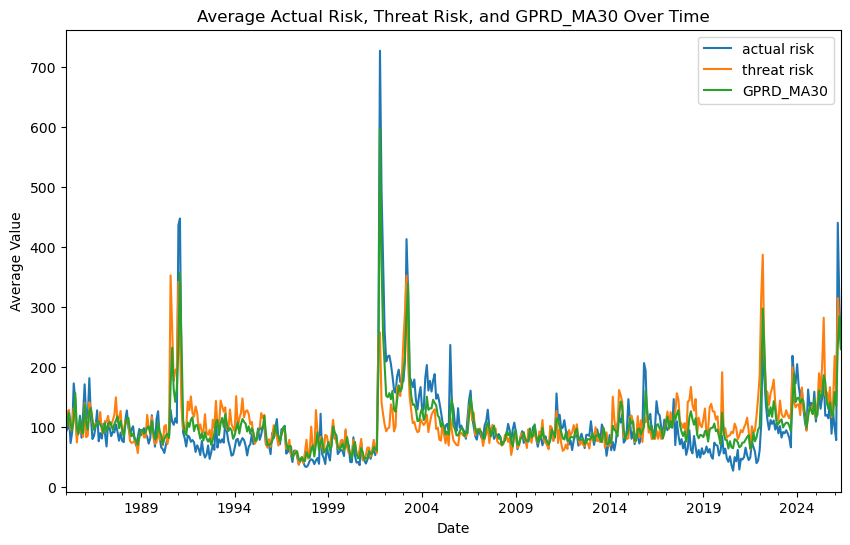

In [ ]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
df_plot1.plot(kind='line', figsize=(10, 6))
plt.title('Average Actual Risk, Threat Risk, and GPRD_MA30 Over Time')
plt.xlabel('Date')
plt.ylabel('Average Value') 

/var/folders/tr/c1v4h6d52wz37ftv4v9rd_n80000gn/T/ipykernel_18397/3185657602.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_merged.groupby('risk_group'):


<Figure size 800x500 with 0 Axes>

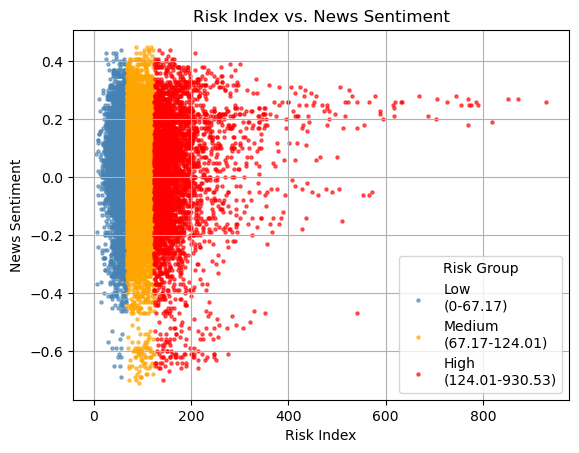

In [ ]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize=(8, 5))
ax = plt.subplots()[1]
colors = {'Low\n(0-67.17)': 'steelblue', 
          'Medium\n(67.17-124.01)': 'orange', 
          'High\n(124.01-930.53)': 'red'}
for group, data in df_merged.groupby('risk_group'):
        ax.scatter(
        data[
            'risk index'],
        data['News Sentiment'],
        label=group,
        color=colors[group],
        alpha=0.6,
        s=5
    )
plt.title('Risk Index vs. News Sentiment')
plt.xlabel('Risk Index')
plt.ylabel('News Sentiment')
plt.grid(True)
ax.legend(title='Risk Group')
plt.show()

In [210]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm

df_merged['risk index'] = pd.to_numeric(df_merged['risk index'], errors='coerce')
df_merged['News Sentiment'] = pd.to_numeric(df_merged['News Sentiment'], errors='coerce')
X_real = df_merged['risk index']
y_real = df_merged['News Sentiment']
X_real_const = sm.add_constant(X_real)
X_real_const.head(2)

,const,risk index
0,1.0,230.04
1,1.0,115.68


In [214]:

model_real = sm.OLS(y_real, X_real_const).fit()
model_real

/var/folders/tr/c1v4h6d52wz37ftv4v9rd_n80000gn/T/ipykernel_18397/907583080.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_merged.groupby('risk_group'):


<Figure size 1000x600 with 0 Axes>

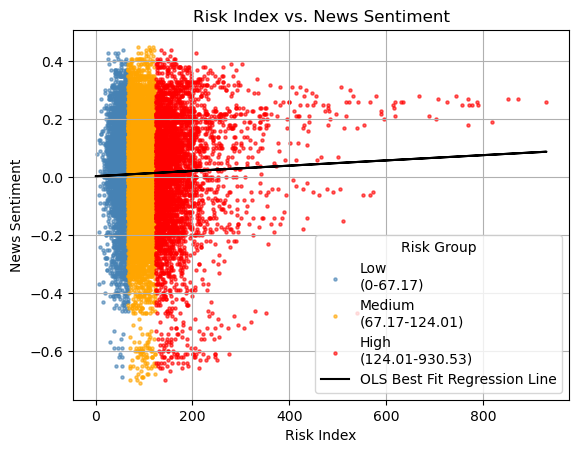

In [218]:
plt.figure(figsize=(10, 6))
ax = plt.subplots()[1]
colors = {'Low\n(0-67.17)': 'steelblue', 
          'Medium\n(67.17-124.01)': 'orange', 
          'High\n(124.01-930.53)': 'red'}
for group, data in df_merged.groupby('risk_group'):
        ax.scatter(
        data[
            'risk index'],
        data['News Sentiment'],
        label=group,
        color=colors[group],
        alpha=0.6,
        s=5
    )

intercept_real, slope_real = model_real.params.iloc[0], model_real.params.iloc[1]

plt.plot(df_merged['risk index'], intercept_real + slope_real * df_merged['risk index'], color='black', label='OLS Best Fit Regression Line')

plt.title('Risk Index vs. News Sentiment')
plt.xlabel('Risk Index')
plt.ylabel('News Sentiment')
plt.grid(True)
ax.legend(title='Risk Group')

plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.